# Movie Review Sentiment Analysis
Beginner-friendly ANN project using the real ACL IMDB dataset.

## Week 5 Structure
Objective | Dataset | Preprocessing | Model Architecture | Training | Evaluation | Extensions | Tools

## 1. Objective
Classify IMDB movie reviews as positive or negative using text tokenization and an ANN.

## 2. Dataset
Real Stanford ACL IMDB movie reviews are used. The official folders are combined first, then the project uses an 80/20 train-test split.


In [1]:
import re
import tarfile
import pathlib
import string
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, models, callbacks

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [2]:
DATA_URL = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
DATA_DIR = pathlib.Path("data")

archive_path = tf.keras.utils.get_file(
    fname="aclImdb_v1.tar.gz",
    origin=DATA_URL,
    cache_dir=".",
    cache_subdir="data",
)

dataset_dir = DATA_DIR / "aclImdb"
if not dataset_dir.exists():
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(path=DATA_DIR)

train_dir = dataset_dir / "train"
test_dir = dataset_dir / "test"

print("Dataset folder:", dataset_dir.resolve())
print("Training folder exists:", train_dir.exists())
print("Test folder exists:", test_dir.exists())

Dataset folder: E:\GNCIPIL\WEEK 5\Movie_Review_Sentiment_Analysis\data\aclImdb
Training folder exists: True
Test folder exists: True


In [3]:
SAMPLES_PER_CLASS = 1000
EPOCHS = 5
BATCH_SIZE = 32
MAX_TOKENS = 10000
SEQUENCE_LENGTH = 250
EMBEDDING_DIM = 64

print("Samples per class from each official folder:", SAMPLES_PER_CLASS)
print("Project split: 80% train, 20% test")
print("Epochs:", EPOCHS)


Samples per class from each official folder: 1000
Project split: 80% train, 20% test
Epochs: 5


## 3. Preprocessing
Load reviews into tables, clean text, and create length features for graphs.

In [4]:
def load_reviews(folder_path, source_name, samples_per_class):
    records = []
    folder_path = pathlib.Path(folder_path)
    for folder, label, label_name in [("neg", 0, "negative"), ("pos", 1, "positive")]:
        files = sorted((folder_path / folder).glob("*.txt"))[:samples_per_class]
        for file_path in files:
            records.append({
                "source_folder": source_name,
                "review": file_path.read_text(encoding="utf-8", errors="ignore"),
                "sentiment": label,
                "sentiment_name": label_name,
                "file_name": file_path.name,
            })
    return pd.DataFrame(records)

source_df = pd.concat([
    load_reviews(train_dir, "official_train", SAMPLES_PER_CLASS),
    load_reviews(test_dir, "official_test", SAMPLES_PER_CLASS),
], ignore_index=True)

train_df, test_df = train_test_split(
    source_df,
    test_size=0.2,
    random_state=SEED,
    stratify=source_df["sentiment"],
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)
train_df["split"] = "train"
test_df["split"] = "test"
reviews_df = pd.concat([train_df, test_df], ignore_index=True)

print("Total reviews used:", len(reviews_df))
print("Training reviews:", len(train_df))
print("Testing reviews:", len(test_df))
display(reviews_df.head())
display(reviews_df.groupby(["split", "sentiment_name"]).size().rename("review_count").reset_index())


Total reviews used: 4000
Training reviews: 3200
Testing reviews: 800


,source_folder,review,sentiment,sentiment_name,file_name,split
0,official_test,This film is a benchmark in non-mainstream cin...,1,positive,10648_9.txt,train
1,official_train,If you're looking to be either offended or amu...,0,negative,10322_2.txt,train
2,official_train,I stopped watching this POS as soon as the sna...,0,negative,10441_1.txt,train
3,official_test,From the opening scenes of FIERCE PEOPLE (an i...,1,positive,10760_8.txt,train
4,official_test,As the metaphoric flies fled this steaming wat...,0,negative,10385_1.txt,train


,split,sentiment_name,review_count
0,test,negative,400
1,test,positive,400
2,train,negative,1600
3,train,positive,1600


In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub("[%s]" % re.escape(string.punctuation), " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

for df in [train_df, test_df, reviews_df]:
    df["clean_review"] = df["review"].apply(clean_text)
    df["char_length"] = df["clean_review"].str.len()
    df["word_count"] = df["clean_review"].str.split().str.len()

reviews_df[["split", "sentiment_name", "clean_review", "word_count"]].head()

,split,sentiment_name,clean_review,word_count
0,train,positive,this film is a benchmark in non mainstream cin...,67
1,train,negative,if you re looking to be either offended or amu...,195
2,train,negative,i stopped watching this pos as soon as the sna...,165
3,train,positive,from the opening scenes of fierce people an in...,495
4,train,negative,as the metaphoric flies fled this steaming wat...,110


## 4. Dataset Visualizations
These graphs show class balance, review length, text size, and frequent words.

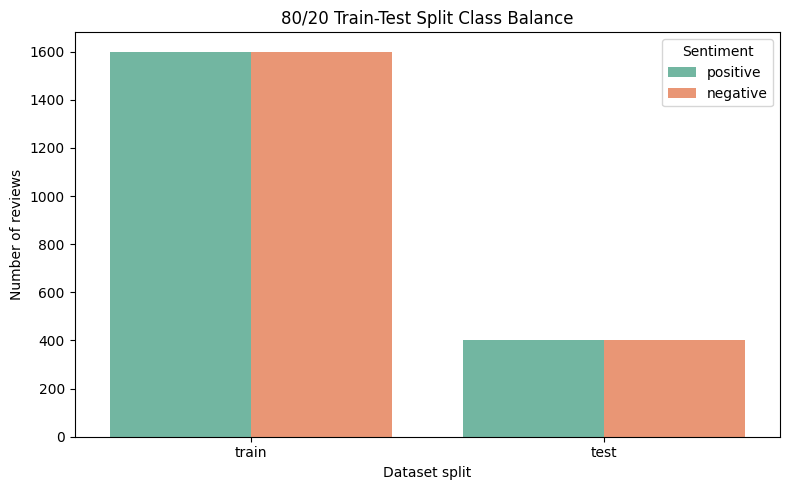

In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(data=reviews_df, x="split", hue="sentiment_name", palette="Set2")
plt.title("80/20 Train-Test Split Class Balance")
plt.xlabel("Dataset split")
plt.ylabel("Number of reviews")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()


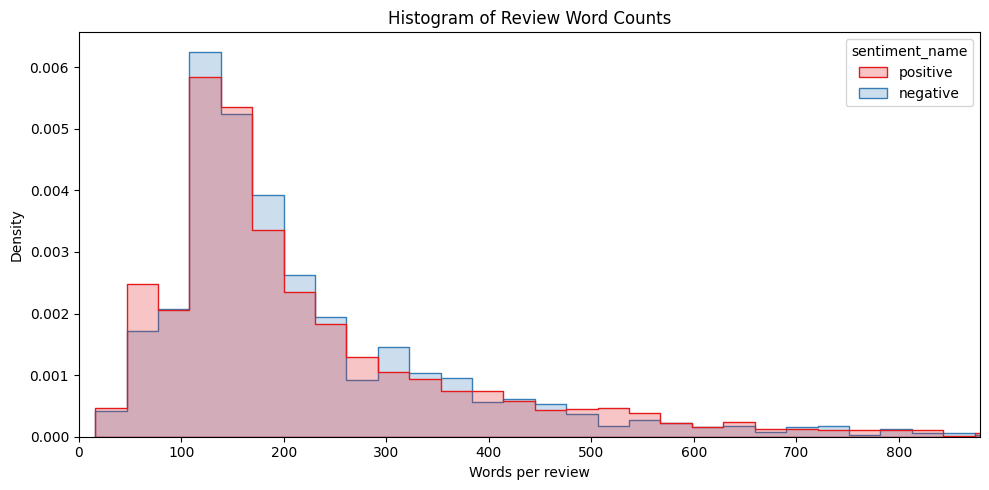

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=reviews_df,
    x="word_count",
    hue="sentiment_name",
    bins=60,
    element="step",
    stat="density",
    common_norm=False,
    palette="Set1",
)
plt.xlim(0, reviews_df["word_count"].quantile(0.99))
plt.title("Histogram of Review Word Counts")
plt.xlabel("Words per review")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

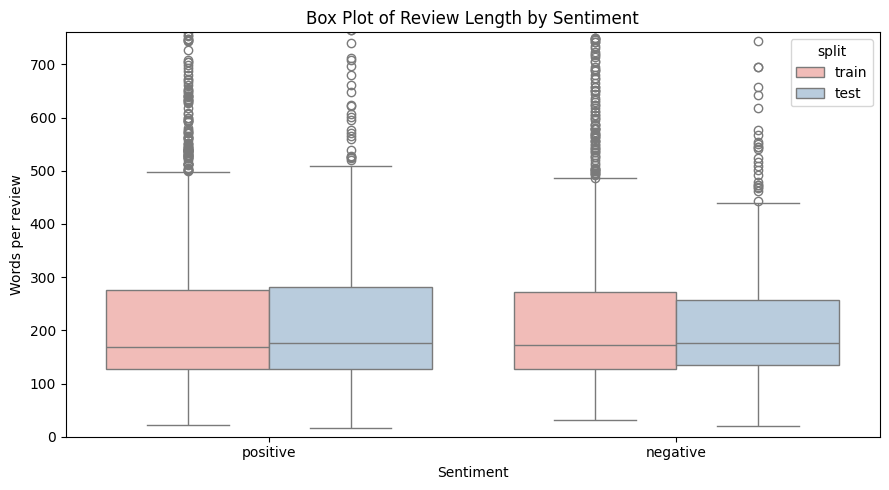

In [8]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=reviews_df, x="sentiment_name", y="word_count", hue="split", palette="Pastel1")
plt.ylim(0, reviews_df["word_count"].quantile(0.98))
plt.title("Box Plot of Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Words per review")
plt.tight_layout()
plt.show()

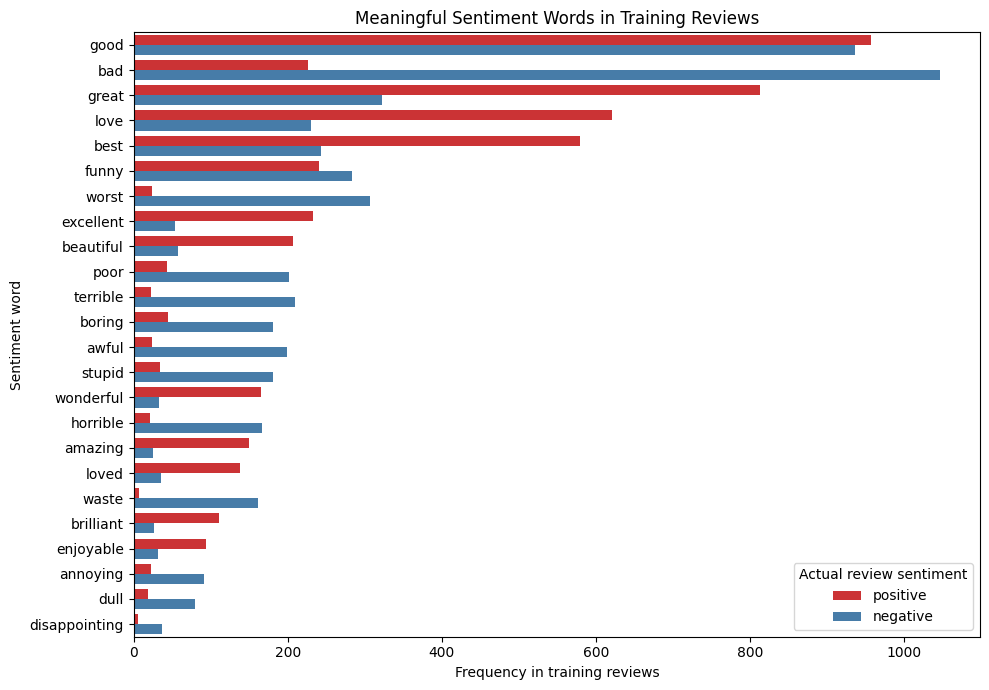

In [9]:
positive_terms = ["good", "great", "excellent", "amazing", "wonderful", "best", "love", "loved", "beautiful", "funny", "brilliant", "enjoyable"]
negative_terms = ["bad", "worst", "boring", "terrible", "awful", "poor", "waste", "dull", "disappointing", "stupid", "annoying", "horrible"]
sentiment_terms = positive_terms + negative_terms

positive_counter = Counter()
negative_counter = Counter()

for review in train_df.loc[train_df["sentiment_name"] == "positive", "clean_review"]:
    positive_counter.update(review.split())

for review in train_df.loc[train_df["sentiment_name"] == "negative", "clean_review"]:
    negative_counter.update(review.split())

keyword_rows = []
for word in sentiment_terms:
    keyword_rows.append({"word": word, "sentiment_name": "positive", "count": positive_counter[word]})
    keyword_rows.append({"word": word, "sentiment_name": "negative", "count": negative_counter[word]})

keyword_df = pd.DataFrame(keyword_rows)
keyword_order = keyword_df.groupby("word")["count"].sum().sort_values(ascending=False).index

plt.figure(figsize=(10, 7))
sns.barplot(data=keyword_df, x="count", y="word", hue="sentiment_name", order=keyword_order, palette="Set1")
plt.title("Meaningful Sentiment Words in Training Reviews")
plt.xlabel("Frequency in training reviews")
plt.ylabel("Sentiment word")
plt.legend(title="Actual review sentiment")
plt.tight_layout()
plt.show()


## 5. Model Architecture
TextVectorization -> Embedding -> GlobalAveragePooling1D -> Dense -> Dropout -> Sigmoid.

In [10]:
X = train_df["clean_review"].values
y = train_df["sentiment"].values
X_test = test_df["clean_review"].values
y_test = test_df["sentiment"].values

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    standardize=None,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH,
)
vectorizer.adapt(X_train)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))
print("Vocabulary size:", len(vectorizer.get_vocabulary()))

Training samples: 2560
Validation samples: 640
Test samples: 800
Vocabulary size: 10000


In [11]:
model = models.Sequential([
    tf.keras.Input(shape=(), dtype=tf.string),
    vectorizer,
    layers.Embedding(input_dim=MAX_TOKENS, output_dim=EMBEDDING_DIM),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 250)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 250, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 646,273 (2.47 MB)

 Trainable params: 646,273 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Training
Train the ANN with Adam, binary crossentropy, batch size 32, and EarlyStopping.

In [12]:
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
)

Epoch 1/5


 1/80 ━━━━━━━━━━━━━━━━━━━━ 2:13 2s/step - accuracy: 0.5625 - loss: 0.6927 - precision: 0.5357 - recall: 0.9375

 9/80 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5119 - loss: 0.6932 - precision: 0.4949 - recall: 0.7299 

18/80 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4937 - loss: 0.6936 - precision: 0.4905 - recall: 0.7031

27/80 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4906 - loss: 0.6937 - precision: 0.4904 - recall: 0.7115

...

50/80 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8807 - loss: 0.2666 - precision: 0.9007 - recall: 0.8574

59/80 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8876 - loss: 0.2564 - precision: 0.9049 - recall: 0.8679

68/80 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8931 - loss: 0.2478 - precision: 0.9083 - recall: 0.8760

77/80 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8974 - loss: 0.2412 - precision: 0.9111 - recall: 0.8818

80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8988 - loss: 0.2390 - precision: 0.9120 - recall: 0.8839 - val_accuracy: 0.7859 - val_loss: 0.4834 - val_precision: 0.9741 - val_recall: 0.5875


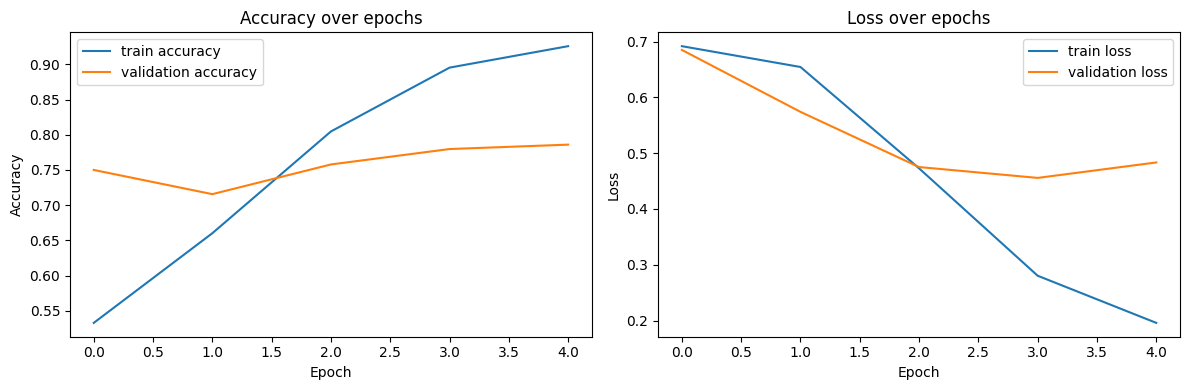

In [13]:
history_df = pd.DataFrame(history.history)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_df["accuracy"], label="train accuracy")
plt.plot(history_df["val_accuracy"], label="validation accuracy")
plt.title("Accuracy over epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["loss"], label="train loss")
plt.plot(history_df["val_loss"], label="validation loss")
plt.title("Loss over epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## 7. Evaluation
Evaluate accuracy, precision, recall, F1 score, confusion matrix, and confidence plots.

In [14]:
test_results = model.evaluate(X_test, y_test, return_dict=True)
pd.Series(test_results).round(4)

 1/25 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7812 - loss: 0.4004 - precision: 0.9000 - recall: 0.6000

15/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7413 - loss: 0.5271 - precision: 0.8778 - recall: 0.5407 

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7386 - loss: 0.5335 - precision: 0.8838 - recall: 0.5377


accuracy     0.7362
loss         0.5452
precision    0.8987
recall       0.5325
dtype: float64

In [15]:
y_prob = model.predict(X_test).ravel()
y_pred = (y_prob >= 0.5).astype(int)

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1_score": f1_score(y_test, y_pred, zero_division=0),
}
metrics_df = pd.DataFrame(metrics.items(), columns=["metric", "score"])

eval_results_df = test_df[["clean_review", "sentiment", "sentiment_name", "word_count"]].copy()
eval_results_df["positive_probability"] = y_prob
eval_results_df["predicted_label"] = y_pred
eval_results_df["predicted_sentiment"] = np.where(y_pred == 1, "positive", "negative")
eval_results_df["correct"] = eval_results_df["sentiment"] == eval_results_df["predicted_label"]

display(metrics_df.round(4))
display(eval_results_df.head())
print(classification_report(y_test, y_pred, target_names=["negative", "positive"], zero_division=0))

 1/25 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step

20/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


,metric,score
0,accuracy,0.7362
1,precision,0.8987
2,recall,0.5325
3,f1_score,0.6688


,clean_review,sentiment,sentiment_name,word_count,positive_probability,predicted_label,predicted_sentiment,correct
0,forget jimmy stewart reliving his life and opt...,1,positive,215,0.991151,1,positive,True
1,i know it is fashionable now to hate this movi...,1,positive,192,0.572783,1,positive,True
2,this film is absolutely appalling and awful it...,0,negative,192,0.010414,0,negative,True
3,great movie good acting a wonderful script it ...,1,positive,65,0.124411,0,negative,False
4,this is a wonderful thriller i watched many ti...,1,positive,61,0.125787,0,negative,False


              precision    recall  f1-score   support

    negative       0.67      0.94      0.78       400
    positive       0.90      0.53      0.67       400

    accuracy                           0.74       800
   macro avg       0.78      0.74      0.72       800
weighted avg       0.78      0.74      0.72       800



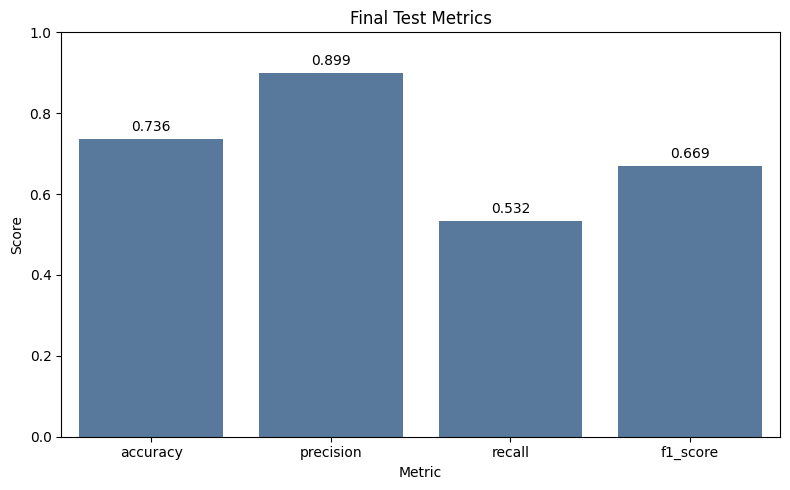

In [16]:
plt.figure(figsize=(8, 5))
sns.barplot(data=metrics_df, x="metric", y="score", color="#4C78A8")
plt.ylim(0, 1)
plt.title("Final Test Metrics")
plt.xlabel("Metric")
plt.ylabel("Score")
for index, row in metrics_df.iterrows():
    plt.text(index, row["score"] + 0.02, f"{row['score']:.3f}", ha="center")
plt.tight_layout()
plt.show()

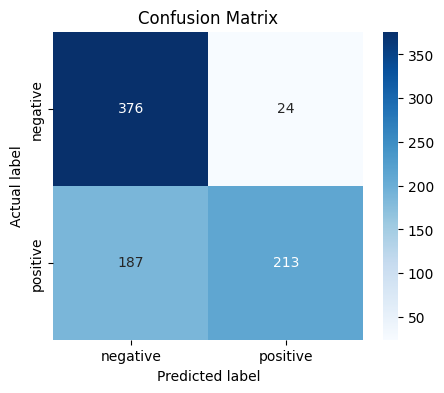

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["negative", "positive"],
    yticklabels=["negative", "positive"],
)
plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.title("Confusion Matrix")
plt.show()

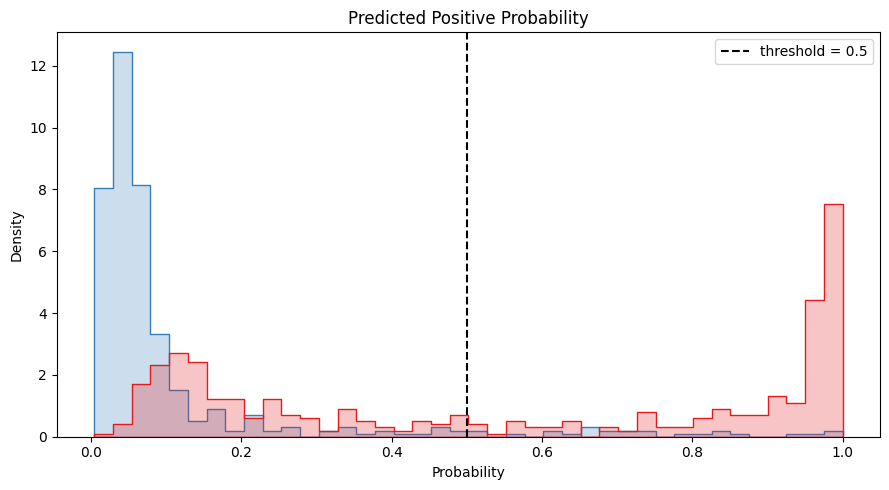

In [18]:
plt.figure(figsize=(9, 5))
sns.histplot(
    data=eval_results_df,
    x="positive_probability",
    hue="sentiment_name",
    bins=40,
    element="step",
    stat="density",
    common_norm=False,
    palette="Set1",
)
plt.axvline(0.5, color="black", linestyle="--", label="threshold = 0.5")
plt.title("Predicted Positive Probability")
plt.xlabel("Probability")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\praya\AppData\Local\Temp\ipykernel_79740\1686046972.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eval_results_df, x="sentiment_name", y="positive_probability", palette="Pastel1")


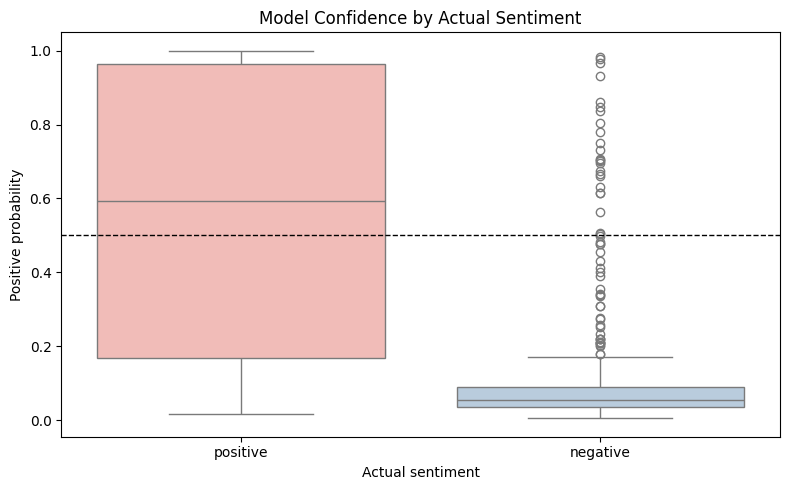

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=eval_results_df, x="sentiment_name", y="positive_probability", palette="Pastel1")
plt.axhline(0.5, color="black", linestyle="--", linewidth=1)
plt.title("Model Confidence by Actual Sentiment")
plt.xlabel("Actual sentiment")
plt.ylabel("Positive probability")
plt.tight_layout()
plt.show()

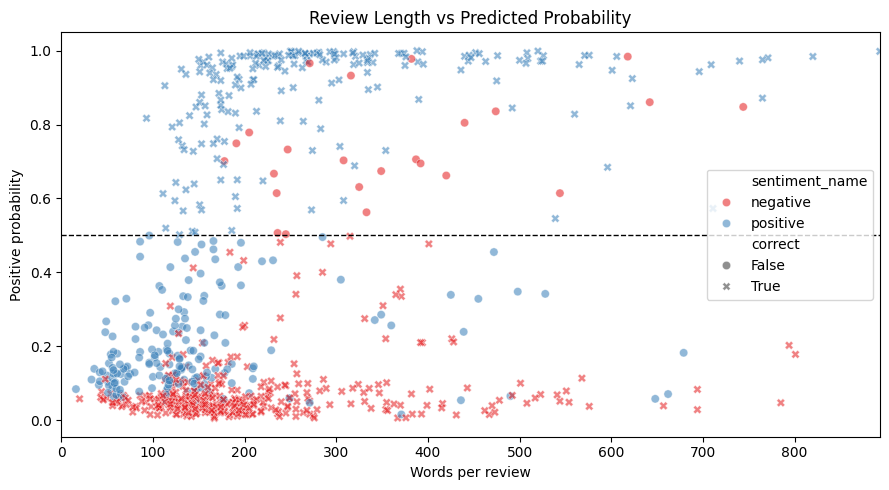

In [20]:
scatter_results = eval_results_df.sample(n=min(2000, len(eval_results_df)), random_state=SEED)

plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=scatter_results,
    x="word_count",
    y="positive_probability",
    hue="sentiment_name",
    style="correct",
    alpha=0.55,
    palette="Set1",
)
plt.axhline(0.5, color="black", linestyle="--", linewidth=1)
plt.xlim(0, scatter_results["word_count"].quantile(0.99))
plt.title("Review Length vs Predicted Probability")
plt.xlabel("Words per review")
plt.ylabel("Positive probability")
plt.tight_layout()
plt.show()

## 8. Prediction
Use the trained model on new reviews.

In [21]:
def predict_sentiment(review_text):
    cleaned_review = clean_text(review_text)
    score = float(model.predict(tf.constant([cleaned_review]), verbose=0)[0][0])
    label = "positive" if score >= 0.5 else "negative"
    return pd.DataFrame([{"review": review_text, "positive_probability": score, "prediction": label}])

predict_sentiment("The movie was emotional, funny, and beautifully performed.")

,review,positive_probability,prediction
0,"The movie was emotional, funny, and beautifull...",0.075064,negative


## 9. Extensions
Tune hyperparameters, compare LSTM/GRU/CNN models, save the model, or deploy a small app.

## 10. Tools
Python, TensorFlow/Keras, pandas, NumPy, scikit-learn, matplotlib, seaborn, Jupyter Notebook.